In [10]:
import pandas as pd
import altair as alt
import numpy as np
alt.data_transformers.enable("vegafusion")

DataTransformerRegistry.enable('vegafusion')

C:\Users\zheng\AppData\Local\Temp\ipykernel_39436\568615768.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(df_genre_avg))  # Use tab10 colormap


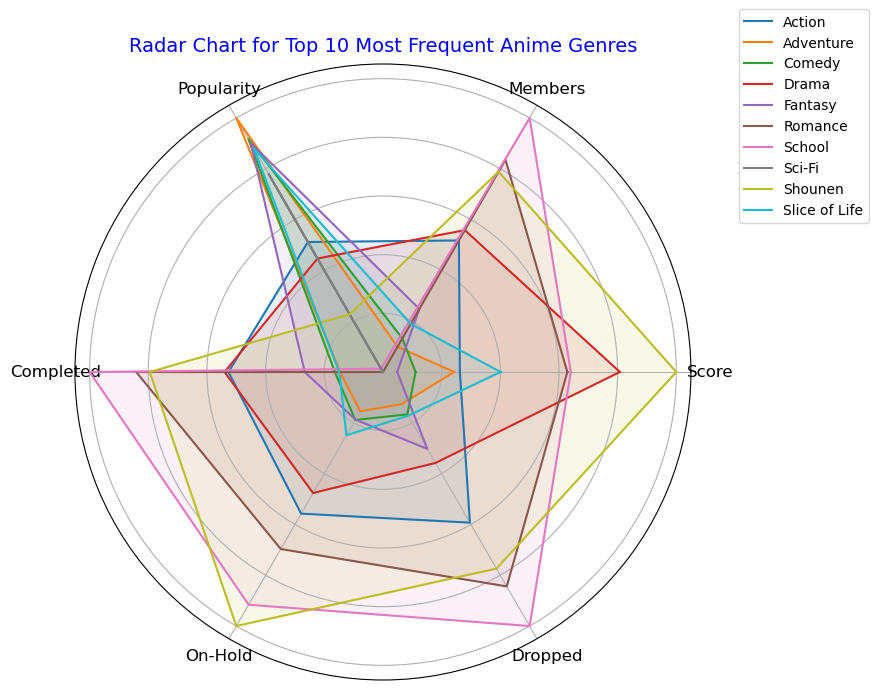

In [14]:
df = pd.read_csv("anime-filtered.csv")

# Explode the Genres column to assign each anime to multiple genres
df_exploded = df.assign(Genres=df['Genres'].str.split(', ')).explode('Genres')

# Count the frequency of each genre and select the top 10 most frequent ones
top_genres = df_exploded['Genres'].value_counts().head(10).index

# Filter dataset to include only the top 10 genres
df_exploded = df_exploded[df_exploded['Genres'].isin(top_genres)]

# Select relevant numerical columns
columns = ['Score', 'Members', 'Popularity', 'Completed', 'On-Hold', 'Dropped']

# Aggregate by genre, computing the mean for each variable
df_genre_avg_original = df_exploded.groupby('Genres')[columns].mean().reset_index()

# Store the original mean data before normalization
df_genre_avg = df_genre_avg_original.copy()

# Normalize values for better visualization (Min-Max Scaling)
df_genre_avg[columns] = (df_genre_avg[columns] - df_genre_avg[columns].min()) / \
                        (df_genre_avg[columns].max() - df_genre_avg[columns].min())

# Number of variables
num_vars = len(columns)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the circle

# Create the radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Define a color map for genres
colors = plt.cm.get_cmap("tab10", len(df_genre_avg))  # Use tab10 colormap

# Plot each of the top 10 genres
for i, row in df_genre_avg.iterrows():
    values = row[columns].values.flatten().tolist()
    values += values[:1]  # Close the circle

    ax.plot(angles, values, linewidth=1.5, linestyle='solid', label=row['Genres'], color=colors(i))
    ax.fill(angles, values, alpha=0.1, color=colors(i))  # Fill area lightly

# Set labels for each axis
ax.set_xticks(angles[:-1])
ax.set_xticklabels(columns, fontsize=12)

# Hide y-axis labels
ax.set_yticklabels([])

# Set title
ax.set_title("Radar Chart for Top 10 Most Frequent Anime Genres", size=14, color='blue', va='bottom')

# Add legend outside the plot
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.show()

In [13]:
df_genre_avg_original

,Genres,Score,Members,Popularity,Completed,On-Hold,Dropped
0,Action,6.723658,73054.542872,5821.529743,47808.727492,2055.350482,2537.760450
1,Adventure,6.716735,49235.019897,7006.458364,32571.523213,1465.653648,1689.389094
2,Cars,6.517347,15356.806122,9556.377551,10616.255102,302.132653,292.704082
3,Comedy,6.669055,51108.738014,6804.930688,33283.676243,1515.250135,1762.130903
4,Dementia,5.374411,21769.075529,10540.815710,13239.308157,604.371601,613.788520
5,Demons,6.704853,66419.298319,5923.069328,41318.493697,2041.485294,2276.970588
6,Drama,6.920768,75360.265866,5663.919811,48337.703688,1936.261578,2110.322470
7,Ecchi,6.484869,85554.425587,4146.791123,58874.866841,1953.785901,3227.339426
8,Fantasy,6.646423,57712.092375,6767.971784,37393.598925,1513.335237,2009.664427
9,Game,6.565263,71319.193906,6912.894737,49566.745152,1710.950139,2511.188366


In [3]:
df_genre_avg

,Genres,Score,Members,Popularity,Completed,On-Hold,Dropped
0,Action,0.804195,0.359577,0.291957,0.369463,0.383543,0.505186
1,Adventure,0.800070,0.241282,0.414066,0.251076,0.273038,0.334263
2,Cars,0.681228,0.073033,0.676840,0.080491,0.055004,0.052870
3,Comedy,0.771651,0.250588,0.393299,0.256609,0.282332,0.348918
4,Dementia,0.000000,0.104878,0.778288,0.100871,0.111641,0.117560
5,Demons,0.792987,0.326625,0.302421,0.319037,0.380944,0.452644
6,Drama,0.921680,0.371028,0.275715,0.373573,0.361226,0.419069
7,Ecchi,0.661870,0.421656,0.119373,0.455443,0.364510,0.644116
8,Fantasy,0.758161,0.283382,0.389490,0.288542,0.281973,0.398789
9,Game,0.709787,0.350959,0.404424,0.383123,0.319005,0.499832
